# Kaggle Dataset Explorer
## Schnelle Datenanalyse für Portfolio-Projekte

Dieses Notebook hilft dir dabei, Kaggle-Datasets schnell zu explorieren und zu entscheiden, ob sie für dein Portfolio-Projekt geeignet sind.

---

## 1. Setup & Daten laden



In [34]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle
import kagglehub


# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100



In [79]:
# ===== HIER DATASET-LINK EINFÜGEN =====
full_link = r"https://www.kaggle.com/datasets/shankarpriya2913/crop-and-soil-dataset"
dataset_link = full_link.split("/datasets/")[-1]
# ======================================

destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

print(f"📦 Lade Dataset: {dataset_name}")
files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
)

print(f"✅ {len(files)} Datei(en) gefunden:")
for i, file in enumerate(files, 1):
    print(f"   {i}. {file}")

📦 Lade Dataset: crop-and-soil-dataset
Destination directory '../data/raw\crop-and-soil-dataset' already exists with files. Skipping download (replace=False).
✅ 1 Datei(en) gefunden:
   1. data_core.csv




## 2. Daten einlesen & erste Inspektion



In [80]:

# Erste CSV-Datei laden (oder bei Bedarf anpassen)
file_path = "/".join([destination, dataset_name, files[0]])
df = pd.read_csv(file_path)

print(f"📊 Geladene Datei: {files[0]}")
print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")

df.sample(10)


📊 Geladene Datei: data_core.csv
📏 Shape: 8,000 Zeilen × 9 Spalten



,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
223,24.76,56.88,20.00,Clayey,Oil seeds,9,0,36,10-26-26
176,35.39,52.28,42.97,Sandy,Pulses,10,17,12,10-26-26
752,32.67,66.69,70.00,Red,Sugarcane,14,7,16,Urea
5362,38.59,59.04,34.17,Clayey,Paddy,14,0,35,20-20
4611,30.34,65.26,61.34,Loamy,Pulses,10,5,35,17-17-17
3896,27.00,53.84,49.81,Clayey,Cotton,24,2,24,DAP
430,24.06,40.20,34.24,Black,Wheat,2,19,12,10-26-26
1194,35.84,62.15,67.16,Sandy,Millets,3,9,26,28-28
1257,30.77,55.44,46.67,Clayey,Paddy,1,5,32,28-28
6242,37.55,64.60,43.06,Loamy,Millets,36,1,0,20-20




---

## 3. Datenqualität & Struktur



In [81]:

print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 8,000 Zeilen × 9 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 1.62 MB


In [82]:
# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Beispielwerte
Temparature,float64,0,0.0,1816,"[25.06, 28.88, 33.91]"
Humidity,float64,0,0.0,3004,"[50.17, 64.85, 59.78]"
Moisture,float64,0,0.0,3723,"[35.01, 26.27, 57.12]"
Soil Type,object,0,0.0,5,"[Red, Sandy, Black]"
Crop Type,object,0,0.0,11,"[Wheat, Cotton, Tobacco]"
Nitrogen,int64,0,0.0,46,"[16, 7, 35]"
Potassium,int64,0,0.0,24,"[0, 0, 6]"
Phosphorous,int64,0,0.0,47,"[33, 11, 2]"
Fertilizer Name,object,0,0.0,7,"[17-17-17, DAP, 14-35-14]"




---

## 4. Numerische Variablen analysieren



In [83]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 6 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
Temparature,8000.0,30.34,4.48,20.00,27.05,30.24,33.46,40.0
Humidity,8000.0,59.21,8.18,40.02,53.28,59.11,65.08,80.0
Moisture,8000.0,43.58,12.60,20.00,33.97,42.25,52.95,70.0
Nitrogen,8000.0,18.43,11.85,0.00,9.00,14.00,26.00,46.0
Potassium,8000.0,3.92,5.49,0.00,0.00,1.00,5.00,23.0
Phosphorous,8000.0,18.51,13.24,0.00,8.00,18.00,30.00,46.0


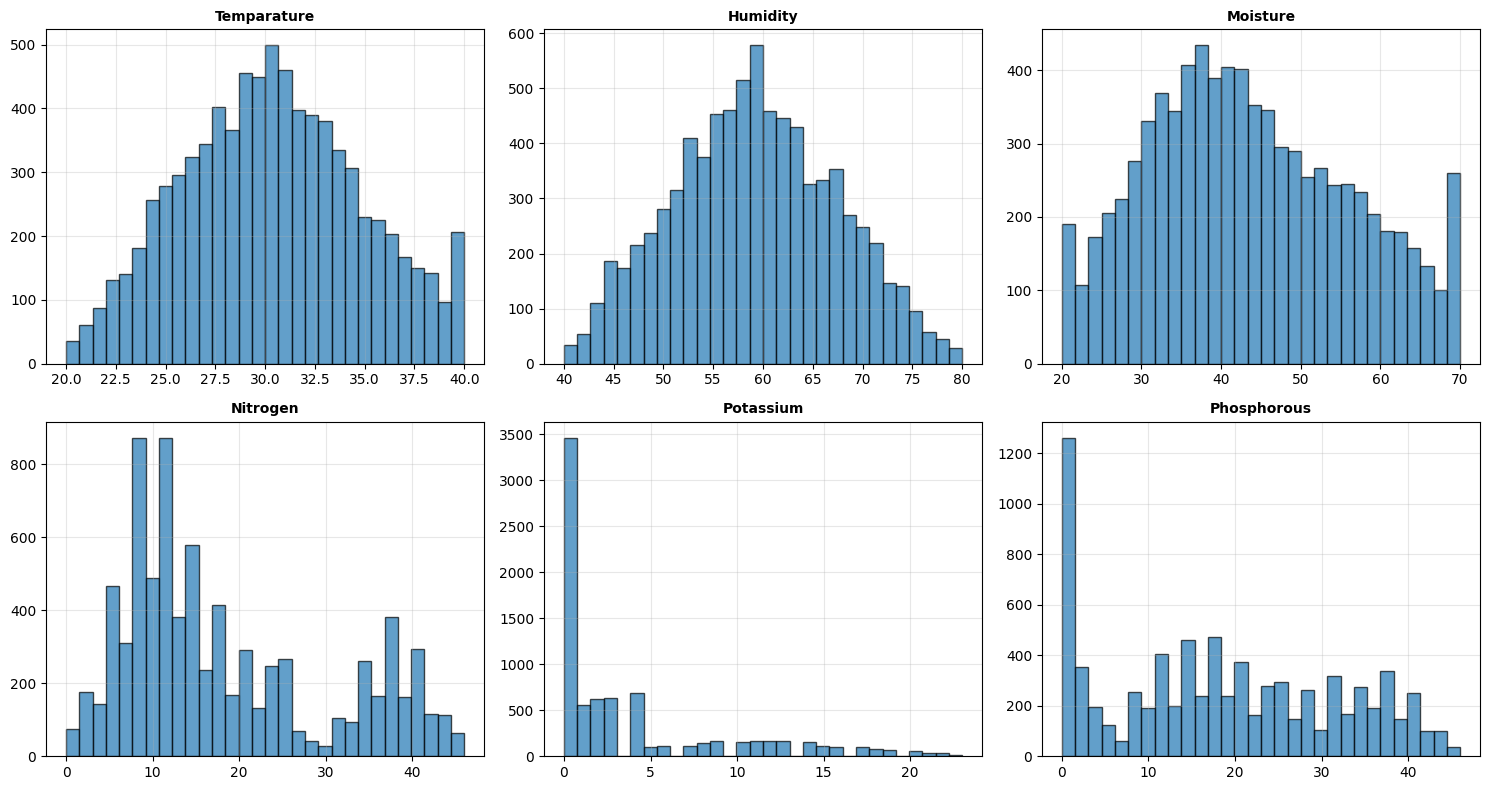

In [84]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()




---

## 5. Kategorische Variablen analysieren



In [85]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


🏷️ 3 kategorische Spalten gefunden



,Spalte,Unique Werte,Häufigste Werte
0,Soil Type,5,"{'Clayey': 1623, 'Black': 1613, 'Red': 1594}"
1,Crop Type,11,"{'Sugarcane': 763, 'Maize': 753, 'Wheat': 747}"
2,Fertilizer Name,7,"{'14-35-14': 1188, 'Urea': 1170, 'DAP': 1167}"


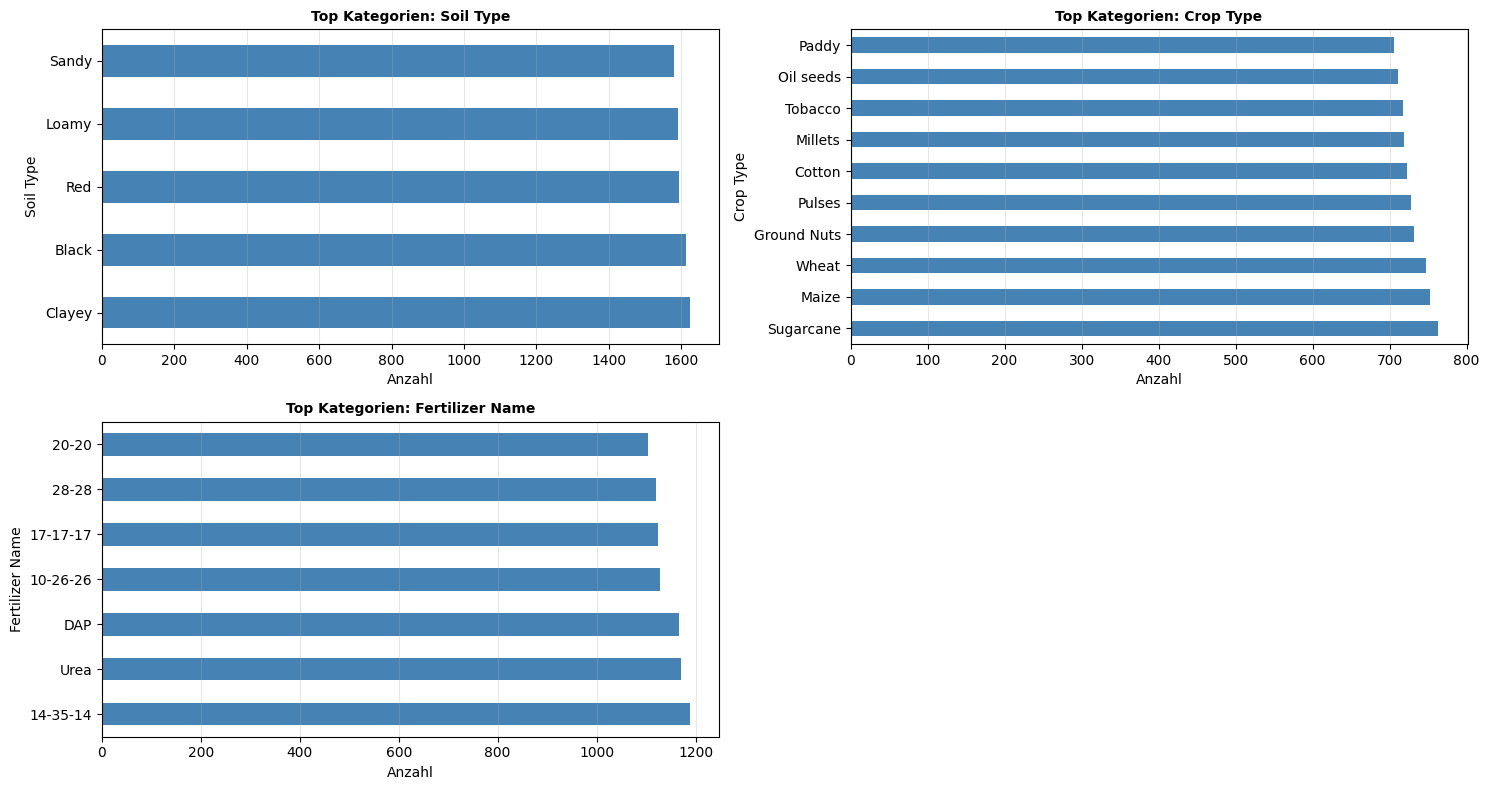

In [86]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()




---

## 6. Korrelationsanalyse



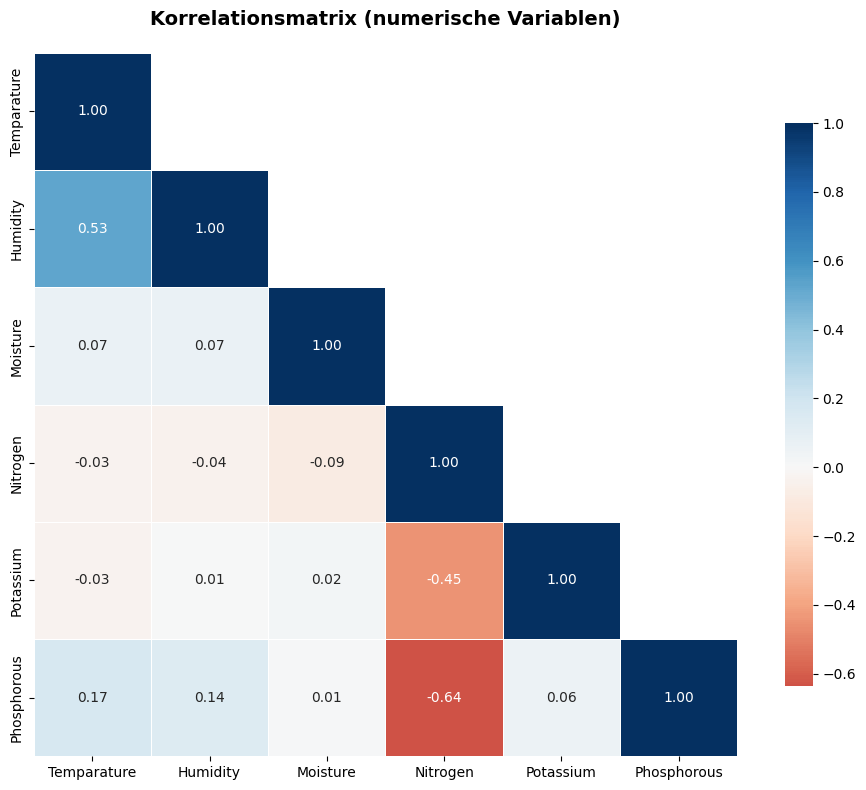


🔗 Stärkste Korrelationen (|r| > 0.5):



,Variable 1,Variable 2,Korrelation
1,Nitrogen,Phosphorous,-0.635694
0,Temparature,Humidity,0.525594


In [87]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [88]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")


✅ Keine fehlenden Werte im Dataset!




---

## 8. Zusammenfassung & Bewertung



In [89]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT
Datengröße.................... ✅ Gut
Vollständigkeit............... ✅ 100.0%
Duplikate..................... ✅ Keine
Variablenvielfalt............. ⚠️ 9 Spalten
Numerische Features........... ✅ 6 Spalten
Kategorische Features......... ✅ 3 Spalten

💡 EMPFEHLUNG:
✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!

📌 Nächste Schritte:
   1. Definiere deine Forschungsfrage
   2. Identifiziere relevante Features
   3. Plane deine Analysestrategie
   4. Beginne mit Feature Engineering & Modeling
